# Water Potability Classification — Data Cleaning & Feature Engineering

Handle missing values, engineer features, encode categoricals, save cleaned dataset.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Handle Missing / Invalid Values

In [3]:
# 3 columns have missing values: ph (~15%), Sulfate (~24%), Trihalomethanes (~5%).
missing = df.isnull().sum()
print('Missing values:'); print(missing[missing > 0])
df_clean = df.copy()

Missing values:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64


## 3. Imputation

In [4]:
# Median imputation per column
df_imputed = df_clean.copy()
for col in df_imputed.columns:
    if df_imputed[col].isnull().sum() > 0:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
print('Missing after imputation:', df_imputed.isnull().sum().sum())

Missing after imputation: 0


## 4. Distribution Comparison Before vs After Imputation

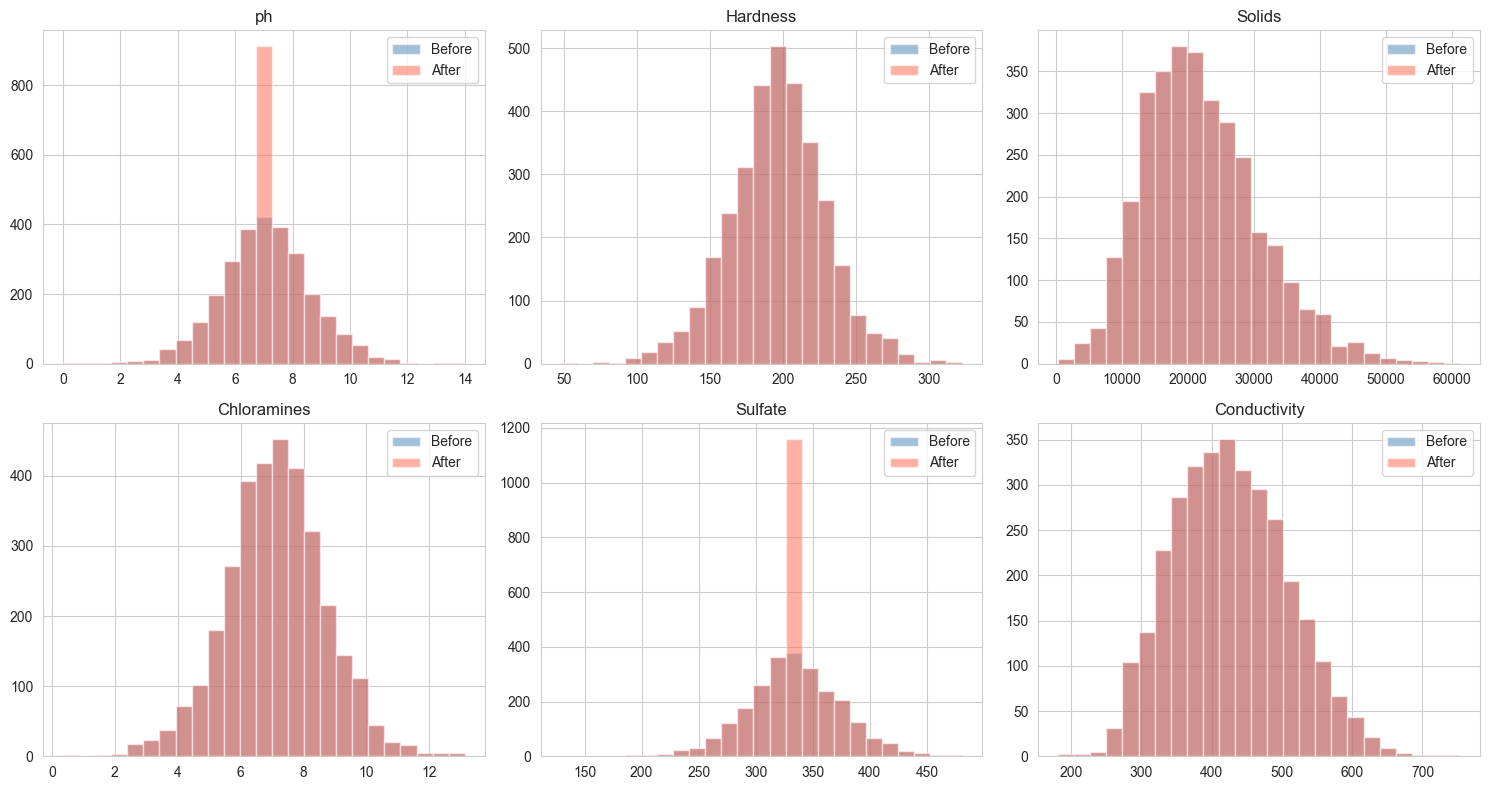

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (3276, 15)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,pH_Category,Hardness_Category,Solids_Category,TotalChemicals,pH_Hardness_Product
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,Neutral,VeryHard,Mid,19.684473,1.441763
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,Acidic,Hard,Mid,15.598889,0.480946
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,Alkaline,VeryHard,Mid,19.248628,1.816117
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,Alkaline,VeryHard,High,21.662361,1.782893
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,Alkaline,VeryHard,Mid,12.847757,1.646615


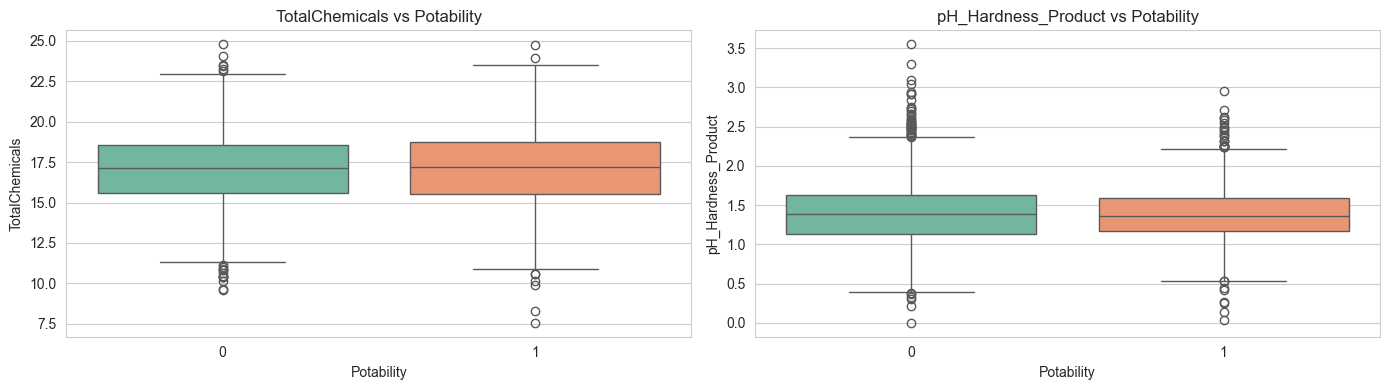

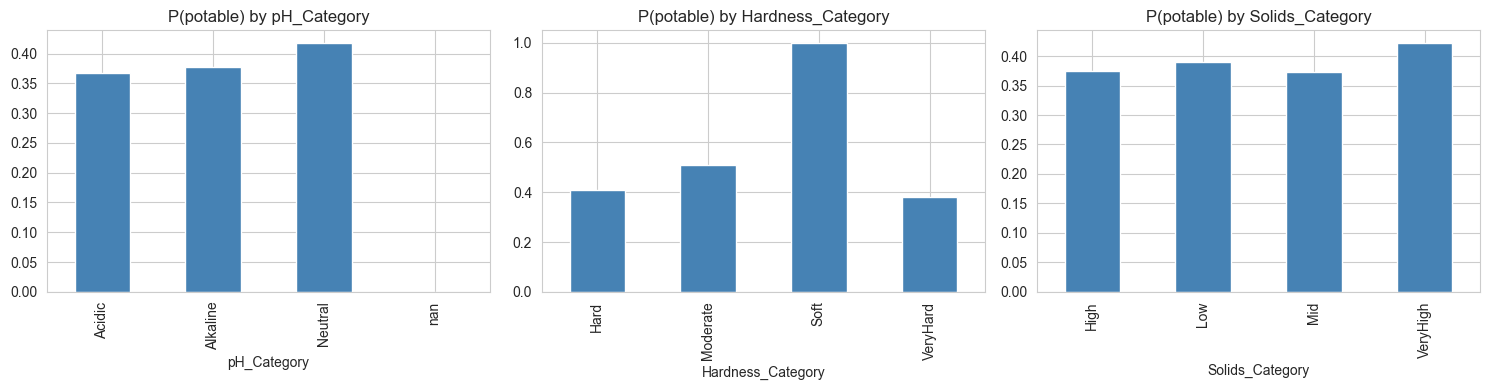

In [7]:
# Engineered features vs Potability
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['TotalChemicals', 'pH_Hardness_Product']):
    if col in df_feat.columns:
        sns.boxplot(x='Potability', y=col, data=df_feat, ax=ax, palette='Set2')
        ax.set_title(f'{col} vs Potability')
plt.tight_layout(); plt.show()
# Categorical bins vs Potability
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['pH_Category', 'Hardness_Category', 'Solids_Category']):
    if col in df_feat.columns:
        rate = df_feat.groupby(col)['Potability'].mean()
        rate.plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'P(potable) by {col}')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('After encoding:', df_encoded.shape)

Categorical columns: ['pH_Category', 'Hardness_Category', 'Solids_Category']
After encoding: (3276, 21)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/water_potability_cleaned.csv', index=False)
print('Saved -> data/water_potability_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (3276, 21)


Saved -> data/water_potability_cleaned.csv


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,TotalChemicals,pH_Hardness_Product,pH_Category_Alkaline,pH_Category_Neutral,pH_Category_nan,Hardness_Category_Moderate,Hardness_Category_Soft,Hardness_Category_VeryHard,Solids_Category_Low,Solids_Category_Mid,Solids_Category_VeryHigh
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,19.684473,1.441763,0,1,0,0,0,1,0,1,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,15.598889,0.480946,0,0,0,0,0,0,0,1,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,19.248628,1.816117,1,0,0,0,0,1,0,1,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,21.662361,1.782893,1,0,0,0,0,1,0,0,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,12.847757,1.646615,1,0,0,0,0,1,0,1,0
